# IN718_twins frame 1148 overlap extraction

This notebook extracts every connected segmented spot from frame 1148 and renders the overlapping raw spot example for thesis figures. The segmentation frame is orientation-corrected with `np.rot90(frame[::-1], k=-1)`; the raw detector frame is left unchanged, matching `spot_browser.ipynb`.

In [13]:
from pathlib import Path
from IPython.display import Image, display

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "extract_spots":
    PROJECT_DIR = PROJECT_DIR.parent

SCRIPT = PROJECT_DIR / "extract_spots" / "extract_IN718_twins_frame_1148.py"
OUT_DIR = PROJECT_DIR / "prediction_previews" / "IN718_twins_frame_1148_overlap"

SCRIPT, OUT_DIR

(PosixPath('/var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/Code/extract_spots/extract_IN718_twins_frame_1148.py'),
 PosixPath('/var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/Code/prediction_previews/IN718_twins_frame_1148_overlap'))

## Generate extraction files

In [14]:
import runpy

runpy.run_path(str(SCRIPT), run_name="__main__")

Saved 774 frame-1148 components to /var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/Code/prediction_previews/IN718_twins_frame_1148_overlap/IN718_twins_frame_1148_spots.h5
Metadata: /var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/Code/prediction_previews/IN718_twins_frame_1148_overlap/IN718_twins_frame_1148_spots.csv
Overlap candidate: spot_0505 bbox_yx=[1758, 1613, 1907, 1774] area=15361
Figures in: /var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/Code/prediction_previews/IN718_twins_frame_1148_overlap


{'__name__': '__main__',
 '__doc__': None,
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': '/var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/Code/extract_spots/extract_IN718_twins_frame_1148.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='builtins', loader=<class '_frozen_importlib.BuiltinImporter'>, origin='built-in'),
  '__build_class__': <function __build_class__>,
  '__import__': <

## Thesis crop

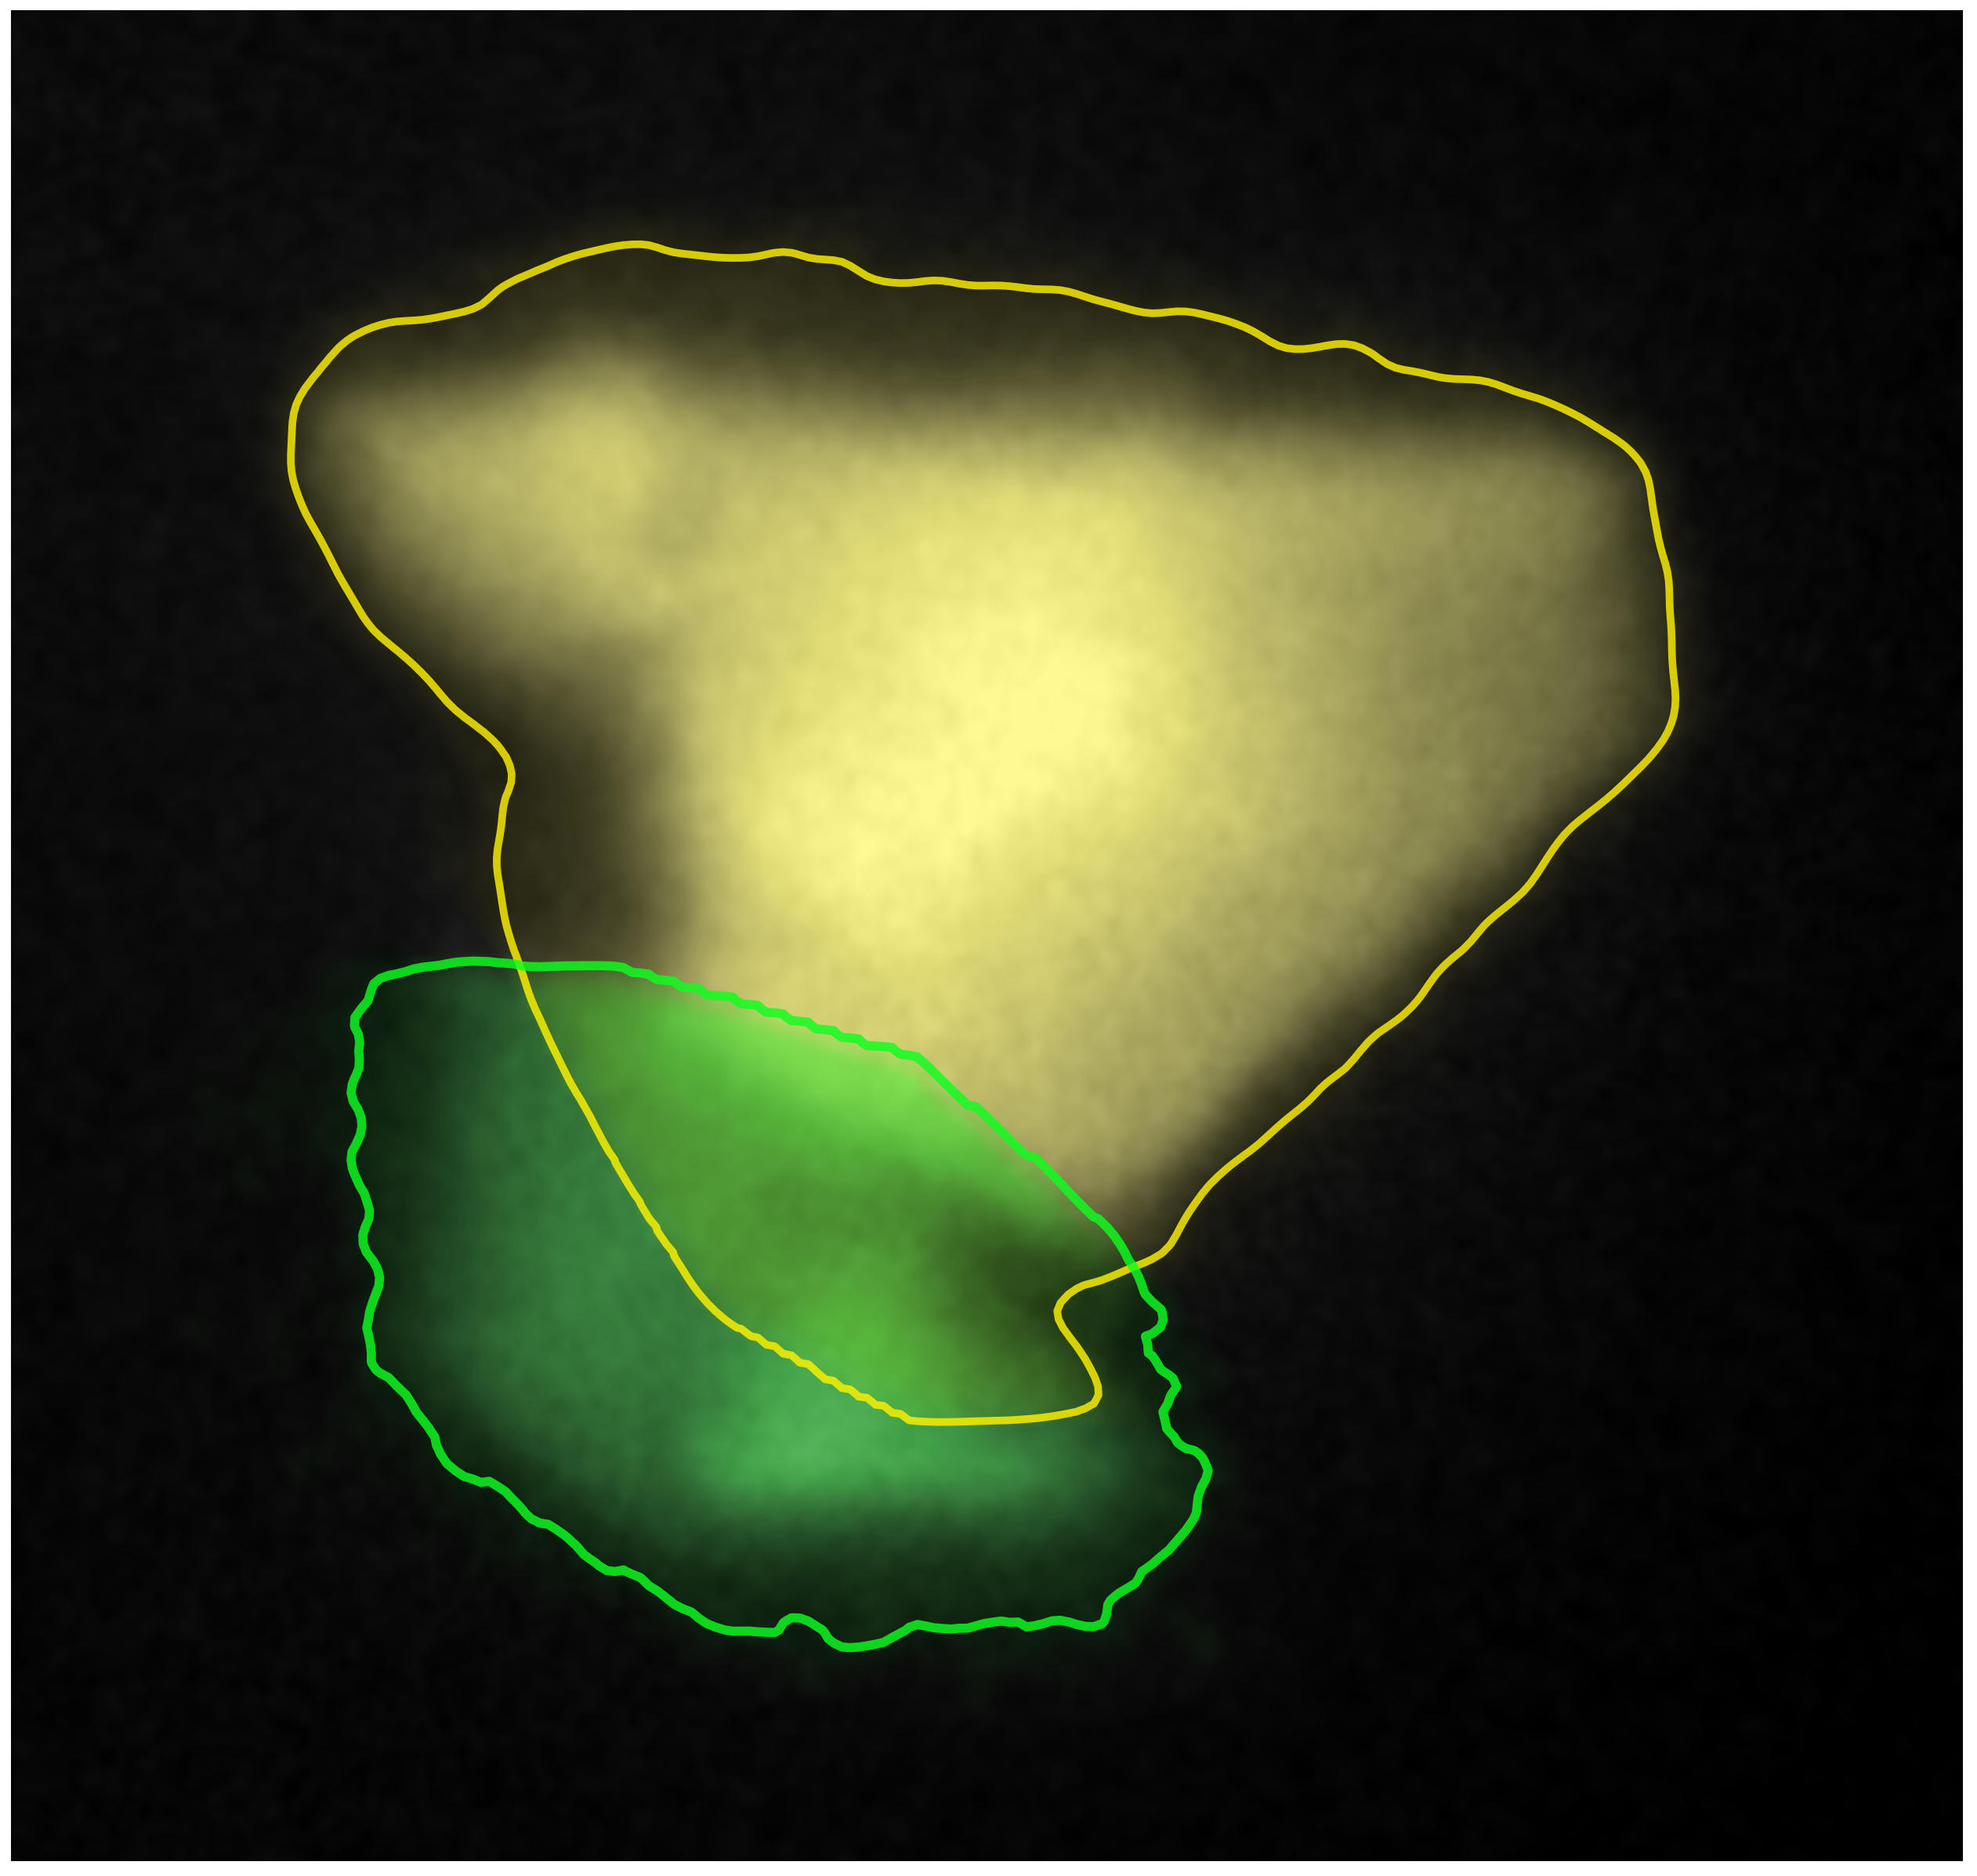

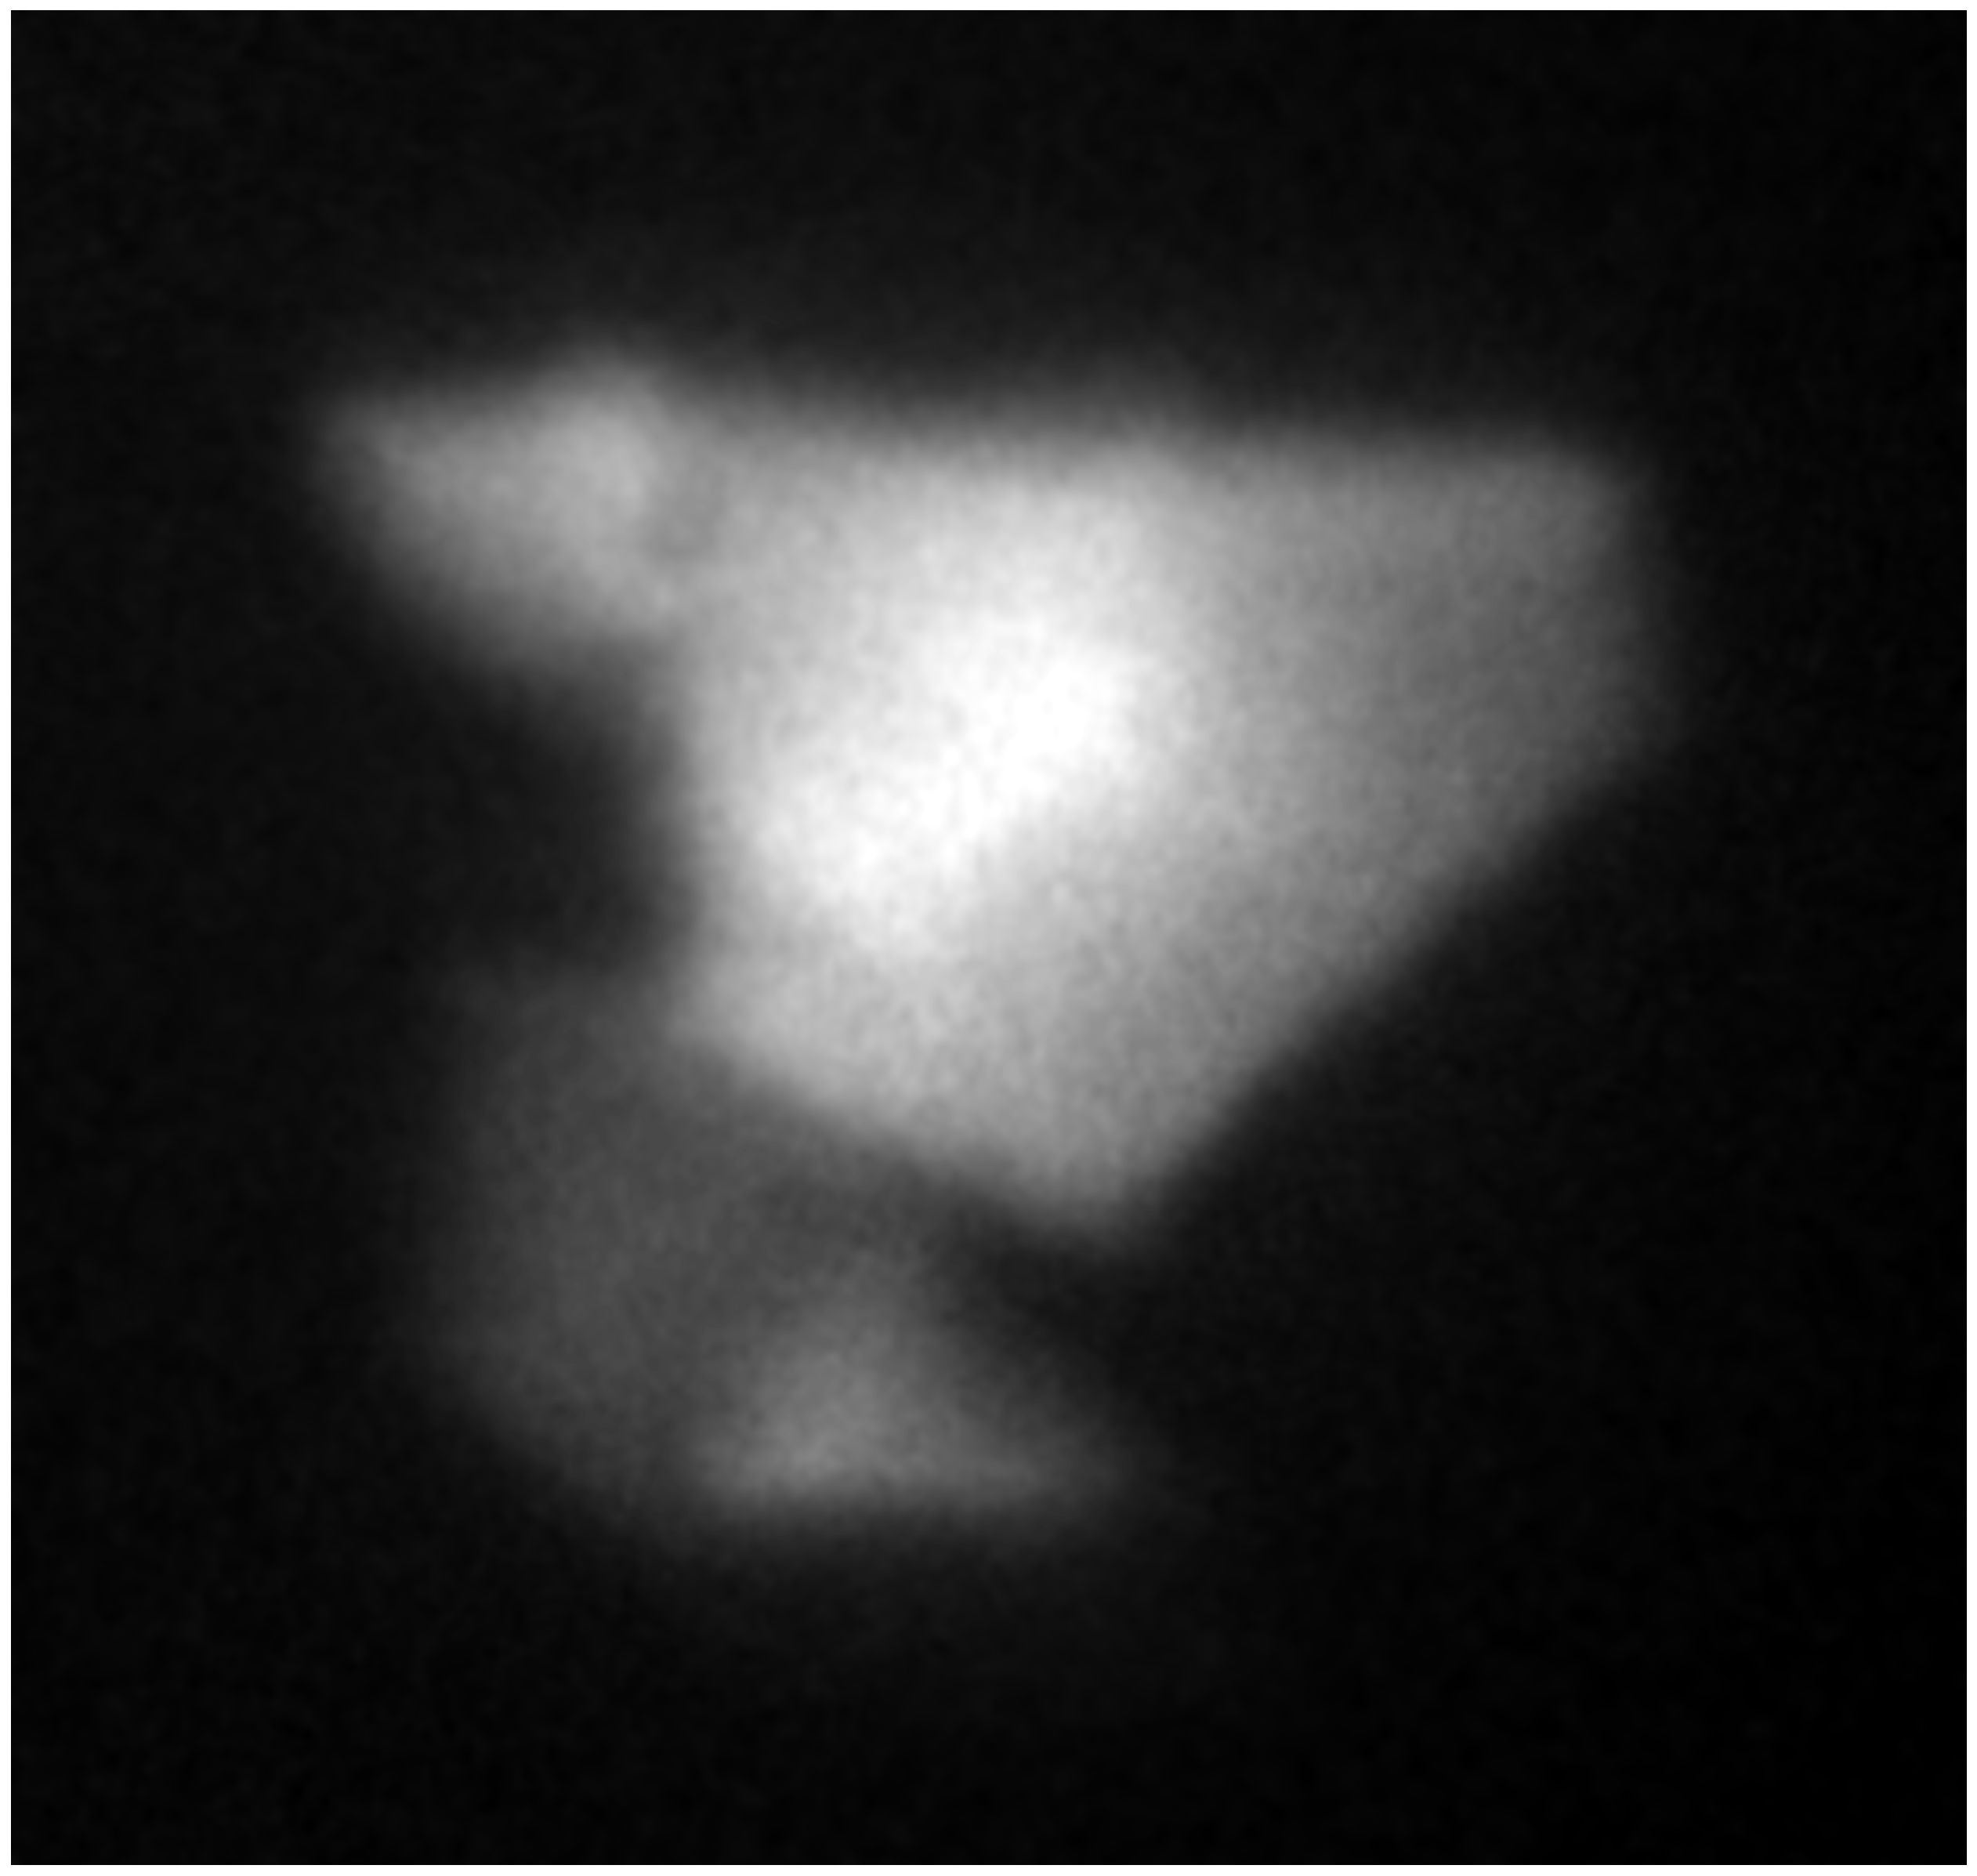

In [15]:
display(Image(filename=str(OUT_DIR / "IN718_twins_frame_1148_overlap_annotated.png")))
display(Image(filename=str(OUT_DIR / "IN718_twins_frame_1148_overlap_raw_crop.png")))

## Output files and overlap metadata

In [ ]:
import csv

for path in sorted(OUT_DIR.iterdir()):
    print(f"{path.name:52s} {path.stat().st_size:>10,d} bytes")

with (OUT_DIR / "IN718_twins_frame_1148_spots.csv").open() as handle:
    rows = list(csv.DictReader(handle))

overlap = next(row for row in rows if row["is_overlap_candidate"] == "True")
print("\nOverlap candidate:")
for key in ["label", "area", "y0", "x0", "y1", "x1", "raw_min", "raw_max", "raw_mean", "raw_sum"]:
    print(f"{key:8s}: {overlap[key]}")
print(f"\nTotal components in frame 1148: {len(rows)}")

Notes: the yellow and green intensity-aware overlays in the annotated image are a visual guide for the two apparent spots; their blended area marks the visual overlap, not a manually validated ground-truth separation. For quantitative work, use the saved connected-component mask in `IN718_twins_frame_1148_spots.h5`.